# Tier 16: hot and high

Three additions, each defaulting to the earlier behaviour:

- **Atmosphere: ISA plus a temperature offset.** `FlightCondition.temperature_offset_K` (default 0) goes to
  `asb.Atmosphere(altitude=..., temperature_deviation=...)`. That object is used by the flight point, the rotor,
  the turboshaft limits and the aerodynamics. Pressure follows the ISA at the pressure altitude, so a hot day is
  less dense.
- **Turboshaft lapse in density and temperature.** `DensityTemperatureLapse` gives
  P / P_rated = sigma^n (T / T_ISA(h))^-m, which is exactly the Tier 10b sigma^n on a standard day.
  - n = 0.797 is the Tier 10b fit.
  - m is fitted here to the XV-15 95 F take-off power curve.
- **Requirement: OGE hover at a hot/high destination after the mission.** It is flown at the mission's end
  mass and end SOC. The default is 4,000 ft / 95 F, the "4k/95" hot day: ISA + 27.7 K. The hover must last
  60 s and end at or above the emergency SOC floor.

**Sources.** NASA TM X-62407 (1975), XV-15 familiarization document,
https://ntrs.nasa.gov/citations/19750016648:

- fig. 6.2.2: rotor shaft power available per engine, take-off rating, standard day and T = 95 F;
- figs. 5.1.1 / 5.1.2: OGE hover ceiling, standard day / 95 F, UT/W = 1.0, 7 % download (sec. 5.1).

The 95 F curves were digitized for this tier by pixel analysis of the scan at 200 dpi:

- gridlines were located from row and column pixel sums, and the zero-altitude row was checked against the
  axis line;
- each curve was traced row by row and read with a local straight-line fit.

```powershell
uv run jupyter lab notebooks/tier16_hot_high
```

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.turboshaft import DensityTemperatureLapse, density_sea_level_kg_m3
from examples.halo_sizing import HaloRequirements, requirements_tier12b, soc_emergency_floor, solve_halo_sizing
from examples.xv15_hot_day import (Xv15HotDayData, hot_atmosphere, hover_mass_kg, temperature_offset_K,
                                   xv15_engine_hot, xv15_lapse_model)
from examples.xv15_performance import Xv15PowerData, calibrate_figure_of_merit, fit_lapse_exponent

check_log = []


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. The hot-day atmosphere

On a "95 F" day the ambient temperature is 95 F at every pressure altitude, so the offset from ISA grows with
altitude. The offset is taken from AeroSandbox's own standard atmosphere (its smooth ISA differs from the
tabulated one by about 0.3 K at 4,000 ft), so the point is exactly 308.15 K.

In [2]:
altitude_m = 4000 * u.foot
offset_K = float(temperature_offset_K(altitude_m, 308.15))
standard, hot = asb.Atmosphere(altitude=altitude_m), asb.Atmosphere(altitude=altitude_m, temperature_deviation=offset_K)
print(f"4,000 ft: ISA {float(standard.temperature()) - 273.15:.2f} C, 95 F = 35.00 C -> offset ISA + {offset_K:.2f} K")
print(f"density ratio: standard {float(standard.density() / density_sea_level_kg_m3):.4f}, "
      f"hot {float(hot.density() / density_sea_level_kg_m3):.4f}")
check("4k/95 offset is ISA + 27.7 K", abs(offset_K - 27.66) < 0.01)
check("the offset leaves pressure unchanged (pressure altitude)", abs(float(hot.pressure() / standard.pressure()) - 1) < 1e-12)
check("hot-day density = standard x T_ISA / T", abs(float(hot.density() / standard.density())
                                                   - float(standard.temperature() / hot.temperature())) < 1e-9)

4,000 ft: ISA 7.34 C, 95 F = 35.00 C -> offset ISA + 27.66 K
density ratio: standard 0.8873, hot 0.8076
PASS  4k/95 offset is ISA + 27.7 K
PASS  the offset leaves pressure unchanged (pressure altitude)
PASS  hot-day density = standard x T_ISA / T


## 2. Turboshaft temperature lapse, fitted to the XV-15 95 F curve

Digitized 95 F take-off power (rotor shaft hp per engine). The same procedure re-reads the Tier 10b
standard-day curve within 7 shp, so the accuracy is about +/- 10 shp (+/- 15 shp at 12,000 ft, where the dashed
line runs into its label). The curve ends near 13,000 ft.

**Fit.** At one pressure altitude, density scales as 1/T. The model therefore gives
P_95F / P_std = (T / T_ISA)^-(n + m), and n + m is fitted to the paired curves at 0, 4,000, 8,000 and
12,000 ft. This is a data-to-data fit, so the error of the standard-day lapse does not enter it.

n = 0.797 (Tier 10b), m = 2.486, n + m = 3.283
 altitude  ISA+dT  P_95F/P_std data  model   residual
       0    20.0             0.803   0.802    -0.1%
    4000    27.7             0.732   0.734    +0.3%
    8000    35.3             0.670   0.670    +0.1%
   12000    43.3             0.610   0.609    -0.2%

 altitude  digitized  model   residual   (95 F power available)
       0       1103   1102    -0.1%
    2000       1021   1006    -1.5%
    4000        941    917    -2.5%
    6000        864    835    -3.3%
    8000        791    759    -4.0%
   10000        720    689    -4.4%
   12000        647    623    -3.7%
PASS  temperature exponent is physical (2 < m < 3)
PASS  paired 95 F / standard ratios fitted within 1.5 %
PASS  95 F power available within 5 % at every digitized altitude (includes the Tier 10b lapse error)
PASS  standard day reproduces Tier 10b sigma^n exactly


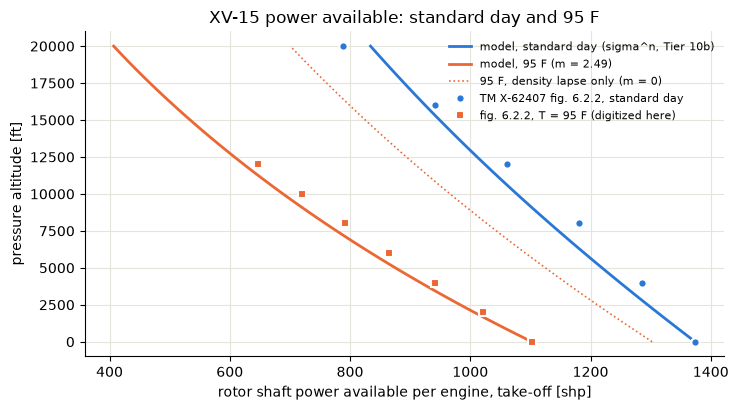

In [3]:
data, standard_data = Xv15HotDayData(), Xv15PowerData()
n = fit_lapse_exponent()
model = xv15_lapse_model(n)
m = model.lapse_exponent_temperature
engine = xv15_engine_hot(model)
print(f"n = {n:.3f} (Tier 10b), m = {m:.3f}, n + m = {n + m:.3f}")
hot_power = dict(zip(data.altitude_power_m, data.power_available_rotor_W))
print(" altitude  ISA+dT  P_95F/P_std data  model   residual")
pair_residuals = []
for h, p in zip(standard_data.altitude_power_m, standard_data.power_available_rotor_W):
    if h in hot_power:
        a = hot_atmosphere(h)
        theta = float(a.temperature() / (a.temperature() - a.temperature_deviation))
        ratio_model, ratio_data = theta**-(n + m), hot_power[h] / p
        pair_residuals.append(ratio_model / ratio_data - 1)
        print(f"{h / u.foot:8.0f}  {float(a.temperature_deviation):6.1f}  {ratio_data:16.3f}  {ratio_model:6.3f}  {pair_residuals[-1]:+7.1%}")
print("\n altitude  digitized  model   residual   (95 F power available)")
power_residuals = []
for h, p in zip(data.altitude_power_m, data.power_available_rotor_W):
    p_model = float(engine.power_available_W(hot_atmosphere(h)))
    power_residuals.append(p_model / p - 1)
    print(f"{h / u.foot:8.0f}  {p / u.hp:9.0f}  {p_model / u.hp:5.0f}  {power_residuals[-1]:+7.1%}")
check("temperature exponent is physical (2 < m < 3)", 2 < m < 3)
check("paired 95 F / standard ratios fitted within 1.5 %", max(abs(r) for r in pair_residuals) < 0.015)
check("95 F power available within 5 % at every digitized altitude (includes the Tier 10b lapse error)",
      max(abs(r) for r in power_residuals) < 0.05)
check("standard day reproduces Tier 10b sigma^n exactly", all(
    float(engine.power_available_W(asb.Atmosphere(altitude=h))) == float(
        standard_data.power_available_rotor_W[0] * (asb.Atmosphere(altitude=h).density() / density_sea_level_kg_m3)**n)
    for h in standard_data.altitude_power_m))

h_plot = np.linspace(0, 20000, 81) * u.foot
density_only = DensityTemperatureLapse(n, 0.0)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot([float(engine.power_available_W(asb.Atmosphere(altitude=h))) / u.hp for h in h_plot], h_plot / u.foot,
        color=blue, lw=2, label="model, standard day (sigma^n, Tier 10b)")
ax.plot([float(engine.power_available_W(hot_atmosphere(h))) / u.hp for h in h_plot], h_plot / u.foot,
        color=orange, lw=2, label=f"model, 95 F (m = {m:.2f})")
ax.plot([standard_data.power_available_rotor_W[0] * float(density_only.power_ratio(hot_atmosphere(h))) / u.hp
         for h in h_plot], h_plot / u.foot, color=orange, lw=1.2, ls=":", label="95 F, density lapse only (m = 0)")
ax.plot(np.array(standard_data.power_available_rotor_W) / u.hp, np.array(standard_data.altitude_power_m) / u.foot,
        "o", color=blue, ms=6, mec="white", mew=1.5, label="TM X-62407 fig. 6.2.2, standard day")
ax.plot(np.array(data.power_available_rotor_W) / u.hp, np.array(data.altitude_power_m) / u.foot,
        "s", color=orange, ms=6, mec="white", mew=1.5, label="fig. 6.2.2, T = 95 F (digitized here)")
ax.set(xlabel="rotor shaft power available per engine, take-off [shp]", ylabel="pressure altitude [ft]",
       title="XV-15 power available: standard day and 95 F")
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

**Reading.** At constant pressure altitude, power falls as (T/T_ISA)^-3.3, about 1.1 % per kelvin. Density
alone (the dotted line) would explain about a quarter of the hot-day loss. The rest is the temperature limit of
the turbine. The temperature term is fitted on the take-off rating only.

## 3. Validation: predicting the 95 F hover weights

This is a prediction, not a fit. It uses the Tier 10b figure of merit, calibrated on the standard day at sea
level, together with the hot-day density at the rotor and the hot-day power available. The comparison is with
fig. 5.1.2's left twin-engine line, the counterpart of the fig. 5.1.1 line that Tier 10b took as take-off
power. The same procedure re-reads that fig. 5.1.1 line within 100 lb.

figure of merit 0.670 (Tier 10b, standard-day sea-level calibration)
 altitude   figure   predicted  error


C:\Users\alexa\Documents\Chasing Amber\halo\.claude\worktrees\agent-a10a81f84a458a276\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


     229    13339      13102   -1.8%
    2000    12445      12149   -2.4%
    4000    11442      11146   -2.6%
    6000    10458      10212   -2.4%
    8000     9546       9343   -2.1%
   10000     8708       8534   -2.0%
   12000     7902       7780   -1.5%
   14000     7046       7078   +0.5%  (above the 95 F power curve: lapse extrapolated)
   16000     6248       6424   +2.8%  (above the 95 F power curve: lapse extrapolated)
   18000     5572       5816   +4.4%  (above the 95 F power curve: lapse extrapolated)
PASS  95 F hover weights predicted within 3 % up to 12,000 ft
PASS  and within 5 % to 18,000 ft (extrapolated lapse)
4,000 ft: standard 14,129 lb, 95 F 11,146 lb (-21.1%)
PASS  the 4k/95 day costs the XV-15 more than 10 % of hover weight


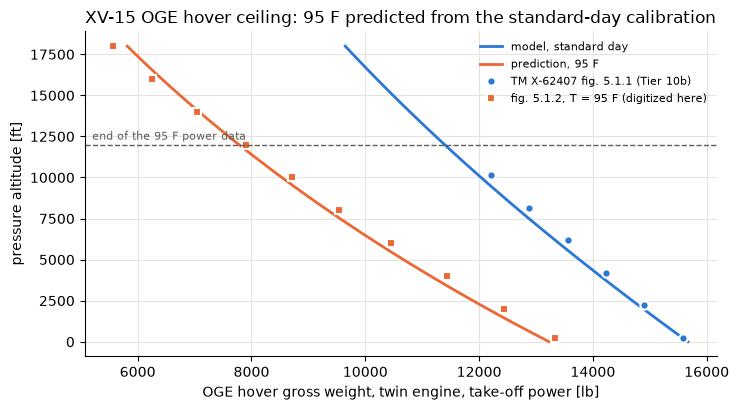

In [4]:
figure_of_merit = calibrate_figure_of_merit(n)
print(f"figure of merit {figure_of_merit:.3f} (Tier 10b, standard-day sea-level calibration)")
print(" altitude   figure   predicted  error")
errors = []
for h, mass in zip(data.altitude_hover_m, data.mass_hover_kg):
    predicted = hover_mass_kg(hot_atmosphere(h), figure_of_merit, model)
    errors.append((h, predicted / mass - 1, predicted))
    note = "" if h <= data.altitude_power_data_max_m + 1 else "  (above the 95 F power curve: lapse extrapolated)"
    print(f"{h / u.foot:8.0f}  {mass / u.lbm:7.0f}  {predicted / u.lbm:9.0f}  {errors[-1][1]:+6.1%}{note}")
inside = [e for h, e, _ in errors if h <= data.altitude_power_data_max_m + 1]
outside = [e for h, e, _ in errors if h > data.altitude_power_data_max_m + 1]
check("95 F hover weights predicted within 3 % up to 12,000 ft", max(abs(e) for e in inside) < 0.03)
check("and within 5 % to 18,000 ft (extrapolated lapse)", max(abs(e) for e in outside) < 0.05)
standard_4k = hover_mass_kg(asb.Atmosphere(altitude=4000 * u.foot), figure_of_merit, model)
hot_4k = hover_mass_kg(hot_atmosphere(4000 * u.foot), figure_of_merit, model)
print(f"4,000 ft: standard {standard_4k / u.lbm:,.0f} lb, 95 F {hot_4k / u.lbm:,.0f} lb ({hot_4k / standard_4k - 1:+.1%})")
check("the 4k/95 day costs the XV-15 more than 10 % of hover weight", hot_4k < 0.9 * standard_4k)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
h_hover = np.linspace(0, 18000, 37) * u.foot
ax.plot([hover_mass_kg(asb.Atmosphere(altitude=h), figure_of_merit, model) / u.lbm for h in h_hover],
        h_hover / u.foot, color=blue, lw=2, label="model, standard day")
ax.plot([hover_mass_kg(hot_atmosphere(h), figure_of_merit, model) / u.lbm for h in h_hover],
        h_hover / u.foot, color=orange, lw=2, label="prediction, 95 F")
ax.plot(np.array(standard_data.mass_hover_kg[:-1]) / u.lbm, np.array(standard_data.altitude_hover_m[:-1]) / u.foot,
        "o", color=blue, ms=6, mec="white", mew=1.5, label="TM X-62407 fig. 5.1.1 (Tier 10b)")
ax.plot(np.array(data.mass_hover_kg) / u.lbm, np.array(data.altitude_hover_m) / u.foot,
        "s", color=orange, ms=6, mec="white", mew=1.5, label="fig. 5.1.2, T = 95 F (digitized here)")
ax.axhline(data.altitude_power_data_max_m / u.foot, color=ink_muted, lw=1, ls="--")
ax.text(5200, data.altitude_power_data_max_m / u.foot + 300, "end of the 95 F power data", color=ink_muted, fontsize=8)
ax.set(xlabel="OGE hover gross weight, twin engine, take-off power [lb]", ylabel="pressure altitude [ft]",
       title="XV-15 OGE hover ceiling: 95 F predicted from the standard-day calibration")
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 4. Halo: hot-day hover at the destination

Reference: fixed 2 x 1,120 hp turboshafts and 900 kg at 210 kt (Tier 12b). The hot-day hover is a capability
point at the mission's end mass and end SOC: 4,000 ft / 95 F, T/W 1.05, 60 s. Its SOC can go down to the
emergency floor of 0.10. It is an alternative contingency to the engine-out reserve, not an addition to it.

`battery_share_min` is the battery share needed when the turbines run at full power available, with the
generators at the point's efficiency. The solved share can be higher wherever the split is free and not
binding.

with the 4k/95 hover: 6,747 kg (14,874 lb); without (Tier 12b): 6,748 kg (14,877 lb)
battery 67.3 kWh / 800 kW; SOC end 0.300, after the hot hover 0.162
 point            altitude  ISA+dT   mass   SOC  rotors kW  turbines avail kW  battery share min / solved  CT/sigma
 hover               4000     0.0   6747  0.80      1575               1518       +0.14 / +0.38     0.140
 take-off hover         0     0.0   6747  0.95      1379               1670       -0.08 / +0.27     0.140
 landing hover          0     0.0   5827  0.30      1107               1670       -0.34 / -0.00     0.140
 hot-day hover       4000    27.7   5820  0.30      1324               1115       +0.25 / +0.39     0.136
PASS  the sizing solves with the hot-day hover and every margin holds
PASS  hot hover flown at the mission end mass and SOC
PASS  SOC after the hot hover stays above the emergency floor
PASS  turbine power available at 4k/95 is under 80 % of the standard 4,000 ft value
PASS  the battery covers a larger sha

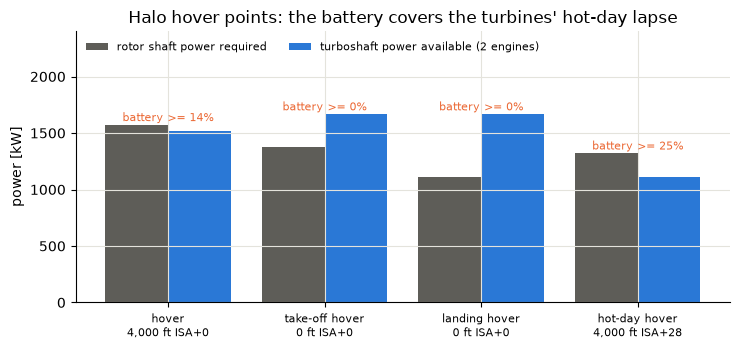

In [5]:
hot_result = solve_halo_sizing()
standard_result = solve_halo_sizing(requirements=requirements_tier12b, initial=hot_result)
print(f"with the 4k/95 hover: {hot_result.mass_takeoff_kg:,.0f} kg ({hot_result.mass_takeoff_kg / u.lbm:,.0f} lb); "
      f"without (Tier 12b): {standard_result.mass_takeoff_kg:,.0f} kg ({standard_result.mass_takeoff_kg / u.lbm:,.0f} lb)")
print(f"battery {hot_result.energy_battery_kWh:.1f} kWh / {hot_result.design.power_max_discharge_battery_W / 1e3:,.0f} kW; "
      f"SOC end {hot_result.soc_end:.3f}, after the hot hover {hot_result.soc_after_hover_hot:.3f}")
print(" point            altitude  ISA+dT   mass   SOC  rotors kW  turbines avail kW  battery share min / solved  CT/sigma")
for h in hot_result.hovers:
    print(f" {h.label:<15} {h.altitude_m / u.foot:8.0f} {h.temperature_offset_K:7.1f} {h.mass_kg:6.0f} {h.soc:5.2f} "
          f"{h.power_rotors_W / 1e3:9.0f} {h.power_available_turboshafts_W / 1e3:18.0f} "
          f"{h.battery_share_min:+11.2f} / {h.hybridization:+.2f} {h.blade_loading:9.3f}")
hovers = {h.label: h for h in hot_result.hovers}
hot_hover = hovers["hot-day hover"]
check("the sizing solves with the hot-day hover and every margin holds", hot_result.min_margin > -1e-6)
check("hot hover flown at the mission end mass and SOC",
      abs(hot_hover.mass_kg - (hot_result.mass_takeoff_kg - hot_result.mass_fuel_burnt_kg)) < 1e-3
      and abs(hot_hover.soc - hot_result.soc_end) < 1e-9)
check("SOC after the hot hover stays above the emergency floor", hot_result.soc_after_hover_hot >= soc_emergency_floor - 1e-6)
check("turbine power available at 4k/95 is under 80 % of the standard 4,000 ft value",
      hot_hover.power_available_turboshafts_W < 0.8 * hovers["hover"].power_available_turboshafts_W)
check("the battery covers a larger share in the hot hover than in the standard-day 4,000 ft hover",
      hot_hover.battery_share_min > hovers["hover"].battery_share_min + 0.05)
check("4k/95 does not resize the reference (within 0.1 %)",
      abs(hot_result.mass_takeoff_kg / standard_result.mass_takeoff_kg - 1) < 1e-3)

labels = [h.label for h in hot_result.hovers]
turbine = [min(h.power_available_turboshafts_W, h.power_rotors_W) / 1e3 for h in hot_result.hovers]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
x = np.arange(len(labels))
ax.bar(x - 0.2, [h.power_rotors_W / 1e3 for h in hot_result.hovers], 0.4, color=ink_muted, label="rotor shaft power required")
ax.bar(x + 0.2, [h.power_available_turboshafts_W / 1e3 for h in hot_result.hovers], 0.4, color=blue,
       label="turboshaft power available (2 engines)")
for xi, h in zip(x, hot_result.hovers):
    ax.text(xi, max(h.power_rotors_W, h.power_available_turboshafts_W) / 1e3 + 30,
            f"battery >= {max(h.battery_share_min, 0):.0%}", ha="center", fontsize=8, color=orange)
ax.set_xticks(x, [f"{h.label}\n{h.altitude_m / u.foot:,.0f} ft ISA{h.temperature_offset_K:+.0f}" for h in hot_result.hovers],
              fontsize=8)
ax.set(ylabel="power [kW]", ylim=(0, 2400), title="Halo hover points: the battery covers the turbines' hot-day lapse")
ax.legend(frameon=False, fontsize=8, loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

### Hotter, higher destinations

This is a continuation in the destination's altitude at 95 F, each solve warm-started from the previous one.

C:\Users\alexa\Documents\Chasing Amber\halo\.claude\worktrees\agent-a10a81f84a458a276\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


4000 ft / 95 F: MTOM  6,748 kg, hot-hover battery share >= 0.25, solidity 0.0709, hot CT/sigma 0.136


4500 ft / 95 F: MTOM  6,748 kg, hot-hover battery share >= 0.27, solidity 0.0709, hot CT/sigma 0.138


CasADi - 2026-10-03 12:19:55 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 190, col 0).") [.../casadi/core/oracle_function.cpp:408]


5000 ft / 95 F: MTOM  6,748 kg, hot-hover battery share >= 0.30, solidity 0.0709, hot CT/sigma 0.139


...

5750 ft / 95 F: MTOM  6,795 kg, hot-hover battery share >= 0.35, solidity 0.0749, hot CT/sigma 0.140


5900 ft / 95 F: MTOM  6,834 kg, hot-hover battery share >= 0.37, solidity 0.0779, hot CT/sigma 0.140


CasADi - 2026-10-03 12:20:12 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 190, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-03 12:20:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 41, col 0).") [.../casadi/core/oracle_function.cpp:408]


6000 ft / 95 F: no closed design found
PASS  battery share of the hot hover rises with destination altitude
PASS  above ~5,500 ft / 95 F the hot hover's blade loading binds and the aircraft grows


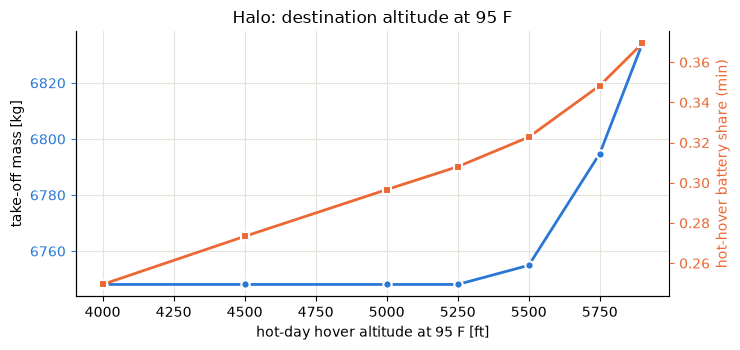

In [6]:
sweep, previous = [], hot_result
for altitude_ft in (4000, 4500, 5000, 5250, 5500, 5750, 5900, 6000):
    try:
        previous = solve_halo_sizing(requirements=replace(HaloRequirements(), altitude_hover_hot_m=altitude_ft * u.foot),
                                     initial=previous)
    except RuntimeError:
        print(f"{altitude_ft} ft / 95 F: no closed design found")
        break
    h = {g.label: g for g in previous.hovers}["hot-day hover"]
    sweep.append((altitude_ft, previous.mass_takeoff_kg, h.battery_share_min, previous.design.solidity, h.blade_loading))
    print(f"{altitude_ft} ft / 95 F: MTOM {previous.mass_takeoff_kg:6,.0f} kg, hot-hover battery share >= "
          f"{h.battery_share_min:.2f}, solidity {previous.design.solidity:.4f}, hot CT/sigma {h.blade_loading:.3f}")
sweep = np.array(sweep)
check("battery share of the hot hover rises with destination altitude", np.all(np.diff(sweep[:, 2]) > 0))
check("above ~5,500 ft / 95 F the hot hover's blade loading binds and the aircraft grows",
      sweep[-1, 1] > sweep[0, 1] + 20 and np.isclose(sweep[-1, 4], 0.14, atol=1e-4))

fig, ax1 = plt.subplots(figsize=(7.5, 3.6))
ax1.plot(sweep[:, 0], sweep[:, 1], color=blue, lw=2, marker="o", ms=6, mec="white", mew=1.5)
ax1.set(xlabel="hot-day hover altitude at 95 F [ft]", ylabel="take-off mass [kg]",
        title="Halo: destination altitude at 95 F")
ax1.tick_params(axis="y", colors=blue)
ax2 = ax1.twinx()
ax2.plot(sweep[:, 0], sweep[:, 2], color=orange, lw=2, marker="s", ms=6, mec="white", mew=1.5)
ax2.set_ylabel("hot-hover battery share (min)", color=orange)
ax2.tick_params(axis="y", colors=orange)
ax2.grid(False)
ax2.spines["right"].set_visible(True)
plt.tight_layout()
plt.show()

## 5. Reading the result

- **The 95 F lapse is mostly temperature, not density.** For the XV-15's LTC1K-4K at take-off rating, power
  at constant pressure altitude falls as (T/T_ISA)^-3.3. The hot-day density term contributes only n = 0.8 of
  that. Using the Tier 10b figure of merit, the fitted lapse predicts the 95 F hover weights within 3 % wherever
  the 95 F power curve exists. That is close to Tier 10b's standard-day accuracy.
- **At 4k/95 the Halo's two 1,120 hp engines deliver 1,115 kW,** against 1,518 kW at 4,000 ft on a standard
  day. At the destination the battery must carry at least a quarter of the hover. That is nearly twice its
  share in the standard-day 4,000 ft hover at take-off mass, and it can carry it.
  - The reference does not grow. The engine-out hover already sizes battery power, and the heavier
    standard-day hover sizes the motors.
  - The hybrid covers the turbines' hot-day lapse at no mass cost, which is why the requirement is on by
    default.
- **Hotter and higher, the limit is the rotor, not the battery.** Above about 5,500 ft / 95 F the hot hover's
  blade loading (CT/sigma = 0.14 at the Mach-limited design tip speed) binds. The optimizer adds solidity,
  and the extra blade area costs cruise power against the fixed engines at 210 kt. From about 6,000 ft / 95 F
  no closed design is found at 900 kg and 210 kt.

## 6. Summary and unit test suite

In [7]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

18 / 18 notebook checks passed


In [8]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 285 tests in 41.399s

OK (skipped=1)
